# Pra-pemrosesan Teks Caption dan Persiapan Data

---

Notebook ini merupakan tahap kedua dari pipeline *image captioning*. Setelah dataset berhasil dieksplorasi, langkah selanjutnya adalah membersihkan teks *caption*, membangun kosakata, mengonversi teks menjadi representasi numerik, dan membagi dataset menjadi subset latiht, validasi, dan uji.

## Latar Belakang dan Tujuan

Data teks mentah tidak dapat langsung digunakan sebagai masukan model. Model hanya dapat memproses data numerik dalam bentuk tensor. Oleh karena itu, diperlukan serangkaian tahap pra-pemrosesan yang mentransformasikan teks *caption* menjadi representasi *integer sequences* yang siap dimasukkan ke dalam *embedding layer*.

Tujuan utama notebook ini adalah:
- Membersihkan teks *caption* dari karakter yang tidak diperlukan;
- Menambahkan token khusus `<start>` dan `<end>` sebagai penanda batas sequence;
- Membangun tokenizer dan mengonversi teks menjadi sequence bilangan bulat;
- Menerapkan *padding* agar seluruh sekuens memiliki panjang yang seragam;
- Membagi dataset menjadi data latih (80%), validasi (10%), dan uji (10%) tanpa kebocoran data (*data leakage*).

## Dasar Teori

### Pembersihan Teks (*Text Cleaning*)

Teks *caption* mentah mengandung berbagai karakter non-alfabetis seperti tanda baca, angka, dan spasi berlebih yang tidak memberikan informasi semantik yang berguna. Proses pembersihan meliputi:
- **Lowercasing:** Mengubah semua huruf menjadi huruf kecil agar kata yang sama dengan kapitalisasi berbeda (misalnya "Dog" dan "dog") dianggap sebagai token yang identik.
- **Penghapusan non-alfabet:** Karakter selain huruf dan spasi dihapus menggunakan ekspresi reguler `[^a-z ]`.
- **Penghapusan spasi berlebih:** Spasi di awal dan akhir kalimat dihilangkan.

### Token Khusus `<start>` dan `<end>`

Model *decoder* membutuhkan sinyal yang jelas kapan harus mulai dan berhenti menghasilkan kata. Token `<start>` ditambahkan di awal setiap *caption* untuk memberi sinyal awal proses dekoding, sementara token `<end>` di akhir menandakan bahwa sekuens telah selesai. Tanpa token ini, model tidak memiliki mekanisme untuk mengontrol panjang keluaran.

### Tokenisasi

Tokenisasi adalah proses mengonversi teks menjadi sekuens bilangan bulat. Setiap kata unik dalam kosakata dipetakan ke sebuah indeks integer. Keras `Tokenizer` digunakan dengan parameter:
- `num_words=VOCAB_SIZE`: Membatasi ukuran kosakata ke 5.000 kata teratas — kata di luar kosakata akan digantikan dengan token `<oov>` (*out-of-vocabulary*).
- `oov_token="<oov>"`: Token khusus untuk kata yang tidak dikenal.
- `filters=""`: Filter default dinonaktifkan karena pembersihan telah dilakukan secara manual.

Tokenizer hanya di-*fit* pada *caption* data latih untuk mencegah kebocoran data (*data leakage*).

### Padding

Model *neural network* membutuhkan masukan dengan dimensi yang tetap (*fixed-size tensor*). Karena panjang setiap *caption* berbeda, kita perlu menyamakan panjang seluruh sekuens melalui *padding* (penambahan nol di akhir sekuens). Parameter `mask_zero=True` pada *Embedding layer* akan mengabaikan nilai nol (hasil *padding*) saat perhitungan *gradient*, sehingga token palsu hasil *padding* tidak memengaruhi proses pembelajaran.

### Pembagian Dataset (*Data Splitting*)

Dataset dibagi berdasarkan **gambar unik**, bukan per baris *caption*. Ini penting untuk mencegah kebocoran data: jika gambar yang sama muncul di lebih dari satu subset, model akan 'mengingat' *caption* dari data latih saat dievaluasi, menghasilkan metrik yang terlalu optimis.

## Impor Pustaka

Pustaka yang digunakan identik dengan notebook sebelumnya, dengan tambahan `Tokenizer` dari Keras dan `train_test_split` dari scikit-learn.

In [1]:
import os
import re
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

2026-07-19 15:42:56.632940: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-19 15:42:56.727218: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-19 15:42:56.768757: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-19 15:42:56.780170: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-19 15:42:56.849487: I tensorflow/core/platform/cpu_feature_guar

## Konfigurasi

    
Konstanta yang digunakan pada notebook ini telah diselaraskan dengan nilai-nilai di `src/config.py`. Parameter penting meliputi:
- `VOCAB_SIZE = 5000` — Ukuran kosakata maksimum;
- `MAX_CAPTION_LEN = 34` — Panjang maksimum sekuens;
- `RANDOM_SEED = 42` — Untuk reproduksibilitas hasil;
- `TEST_SIZE = 0.1` — Proporsi data validasi (10%).

In [2]:
BASE = "../dataset"
CAPTIONS_PATH = os.path.join(BASE, "captions.txt")

MODEL_DIR = "../model"
OUTPUTS_DIR = "../outputs"

VOCAB_SIZE      = 5000
MAX_CAPTION_LEN = 34
RANDOM_SEED     = 42
TEST_SIZE       = 0.2     # 20% for val + test combined
VAL_SIZE        = 0.1     # 10% of total for validation

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

## Metodologi Implementasi

### 5.1 Memuat Dataset

Dataset dimuat dari `dataset/captions.txt` menggunakan `pd.read_csv()`. Dataframe yang dihasilkan memiliki dua kolom: `image` (nama file) dan `caption` (teks *caption*).

In [3]:
df = pd.read_csv(CAPTIONS_PATH)
print(f"Loaded {len(df):,} rows, {df['image'].nunique():,} unique images")
df.head(3)

Loaded 40,455 rows, 8,091 unique images


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .


### 5.2 Pembersihan Caption (*Cleaning*)

Fungsi `clean_caption()` menerapkan tiga langkah pembersihan secara berurutan:
1. **Lowercasing:** `text.lower()` — menyamakan kapitalisasi;
2. **Penghapusan karakter non-alfabet:** `re.sub(r"[^a-z ]", "", text)` — menghapus tanda baca, angka, dan karakter khusus;
3. **Penghapusan spasi berlebih:** `text.strip()` — menghilangkan spasi di awal dan akhir.

Pendekatan ini mempertahankan informasi semantik inti sambil mengurangi ukuran kosakata secara signifikan.

In [4]:
def clean_caption(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^a-z ]", "", text)
    text = text.strip()
    return text

df["clean"] = df["caption"].apply(clean_caption)

# Before vs After
compare = pd.DataFrame({
    "raw": df["caption"].head(3),
    "clean": df["clean"].head(3)
})
compare

,raw,clean
0,A child in a pink dress is climbing up a set o...,a child in a pink dress is climbing up a set o...
1,A girl going into a wooden building .,a girl going into a wooden building
2,A little girl climbing into a wooden playhouse .,a little girl climbing into a wooden playhouse


### 5.3 Penambahan Token `<start>` dan `<end>`

Fungsi `add_tokens()` menambahkan token `<start>` di awal dan `<end>` di akhir setiap *caption* yang telah dibersihkan. Format akhir menjadi:

```
<start> a black dog and a white dog are running through the snow <end>
```

Token `<start>` memiliki indeks 1 dan `<end>` memiliki indeks 2 dalam *word_index* tokenizer.

In [5]:
def add_tokens(text: str) -> str:
    return f"<start> {text} <end>"

df["clean"] = df["clean"].apply(add_tokens)

print("After adding tokens:")
print(df["clean"].iloc[0])

After adding tokens:
<start> a child in a pink dress is climbing up a set of stairs in an entry way <end>


### 5.4 Pembangunan Tokenizer

Tokenizer Keras di-*fit* hanya pada *caption* data latih untuk menghindari kebocoran data. Parameter yang digunakan:
- `num_words=VOCAB_SIZE` (5000) — membatasi ukuran kosakata;
- `oov_token="<oov>"` — token untuk kata di luar kosakata;
- `filters=""` — menonaktifkan filter default.

Setelah tokenizer di-*fit*, *captions* dikonversi menjadi sekuens bilangan bulat menggunakan `texts_to_sequences()`, kemudian dilanjutkan dengan *padding* ke panjang seragam `MAX_CAPTION_LEN`.

In [6]:
# Split by unique image so no image appears in two sets
unique_images = df["image"].unique()

train_imgs, temp_imgs = train_test_split(
    unique_images, test_size=TEST_SIZE, random_state=RANDOM_SEED
)
val_imgs, test_imgs = train_test_split(
    temp_imgs, test_size=0.5, random_state=RANDOM_SEED
)

train_df = df[df["image"].isin(train_imgs)].copy()
val_df   = df[df["image"].isin(val_imgs)].copy()
test_df  = df[df["image"].isin(test_imgs)].copy()

print(f"Train: {len(train_df):,} captions | {len(train_imgs):,} images")
print(f"Val:   {len(val_df):,} captions | {len(val_imgs):,} images")
print(f"Test:  {len(test_df):,} captions | {len(test_imgs):,} images")

Train: 32,360 captions | 6,472 images
Val:   4,045 captions | 809 images
Test:  4,050 captions | 810 images


In [7]:
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<oov>",
    filters=""  # don't strip punctuation — we already cleaned
)
tokenizer.fit_on_texts(train_df["clean"])

vocab_size_actual = min(len(tokenizer.word_index) + 1, VOCAB_SIZE)
print(f"Vocabulary size (capped at {VOCAB_SIZE}): {vocab_size_actual}")
print(f"\nFirst 10 tokens:\n{list(tokenizer.word_index.items())[:10]}")

Vocabulary size (capped at 5000): 5000

First 10 tokens:
[('<oov>', 1), ('a', 2), ('<start>', 3), ('<end>', 4), ('in', 5), ('the', 6), ('on', 7), ('is', 8), ('and', 9), ('dog', 10)]


### 5.5 Konversi ke Sekuens dan Padding

Fungsi `texts_to_padded()` menggabungkan proses konversi teks ke sekuens dan *padding* dalam satu langkah:
1. `tokenizer.texts_to_sequences(texts)` — mengonversi teks ke list of lists of integers;
2. `pad_sequences(sequences, maxlen=MAX_CAPTION_LEN, padding="post")` — menambahkan nol di akhir sekuens hingga mencapai panjang 34.

Parameter `padding="post"` memastikan bahwa nilai nol ditambahkan di akhir sekuens (bukan di awal), sehingga *Embedding layer* dapat mengabaikannya dengan `mask_zero=True`.

In [8]:
def texts_to_padded(tokenizer, texts):
    seq = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=MAX_CAPTION_LEN, padding="post")

X_train_seq = texts_to_padded(tokenizer, train_df["clean"])
X_val_seq   = texts_to_padded(tokenizer, val_df["clean"])
X_test_seq  = texts_to_padded(tokenizer, test_df["clean"])

print(f"Train sequences: {X_train_seq.shape}")
print(f"Val   sequences: {X_val_seq.shape}")
print(f"Test  sequences: {X_test_seq.shape}")
print(f"\nSample sequence (first train caption):\n{X_train_seq[0]}")

Train sequences: (32360, 34)
Val   sequences: (4045, 34)
Test  sequences: (4050, 34)

Sample sequence (first train caption):
[   3    2   43    5    2   90  163    8  115   54    2  384   13  365
    5   29 4703  703    4    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]


### 5.6 Pembuatan Tabel Split Final

Informasi pembagian dataset disimpan dalam dictionary `split_info` yang mencakup daftar nama gambar untuk masing-masing subset (latih, validasi, uji). Data ini akan digunakan oleh notebook-notebook selanjutnya untuk memuat subset yang sesuai tanpa perlu mengulang proses *splitting*.

In [9]:
split_info = {
    "train_images": list(train_imgs),
    "val_images":   list(val_imgs),
    "test_images":  list(test_imgs),
    "train_idx":    train_df.index.tolist(),
    "val_idx":      val_df.index.tolist(),
    "test_idx":     test_df.index.tolist(),
}

print(f"Train images: {len(split_info['train_images'])}")
print(f"Val   images: {len(split_info['val_images'])}")
print(f"Test  images: {len(split_info['test_images'])}")

Train images: 6472
Val   images: 809
Test  images: 810


## Analisis Visual

### 6.1 Distribusi Panjang Sekuens Sebelum Padding

Visualisasi ini menunjukkan distribusi panjang sekuens (dalam jumlah kata) untuk seluruh *caption* dalam dataset.

**Analisis:** Sebagian besar sekuens memiliki panjang antara 8–20 token. Nilai `MAX_CAPTION_LEN=34` yang ditetapkan merupakan batas yang aman untuk menampung hampir seluruh *caption* dengan *padding* yang minimal.

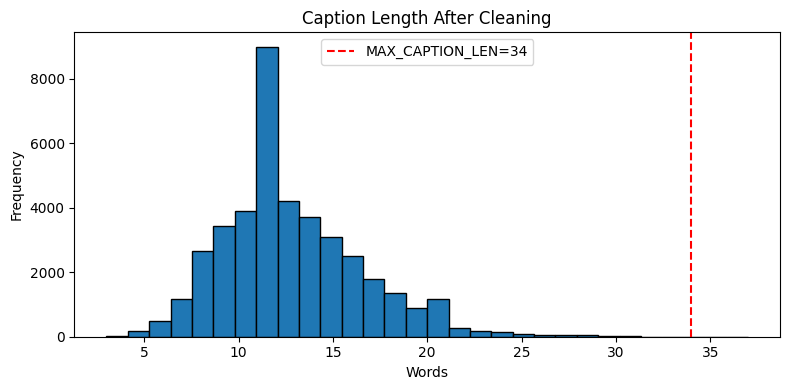

100.0% of captions fit within MAX_CAPTION_LEN (34)


In [10]:
lens = [len(s.split()) for s in df["clean"]]

plt.figure(figsize=(8, 4))
plt.hist(lens, bins=30, edgecolor="black")
plt.axvline(MAX_CAPTION_LEN, color="red", linestyle="--",
            label=f"MAX_CAPTION_LEN={MAX_CAPTION_LEN}")
plt.title("Caption Length After Cleaning")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

pct = sum(l <= MAX_CAPTION_LEN for l in lens) / len(lens) * 100
print(f"{pct:.1f}% of captions fit within MAX_CAPTION_LEN ({MAX_CAPTION_LEN})")

### 6.2 Perbandingan Ukuran Split

Proporsi pembagian dataset divisualisasikan untuk memverifikasi bahwa data telah terbagi sesuai dengan konfigurasi 80/10/10.

**Analisis:** Pembagian dataset menghasilkan:
- **Data latih:** 6.472 gambar (32.360 *caption*);
- **Data validasi:** 809 gambar (4.045 *caption*);
- **Data uji:** 810 gambar (4.050 *caption*).

Proporsi ini sesuai dengan parameter `TEST_SIZE=0.1` yang ditetapkan.

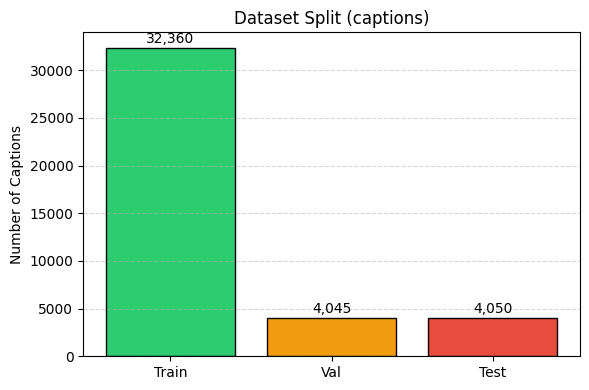

In [11]:
sizes = [len(train_df), len(val_df), len(test_df)]
labels = ["Train", "Val", "Test"]
colors = ["#2ecc71", "#f39c12", "#e74c3c"]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, sizes, color=colors, edgecolor="black")
for bar, val in zip(bars, sizes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f"{val:,}", ha="center", va="bottom")
plt.title("Dataset Split (captions)")
plt.ylabel("Number of Captions")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Analisis Hasil dan Observasi

Proses pra-pemrosesan yang telah dilakukan menghasilkan beberapa temuan penting:

1. **Pembersihan** berhasil mengurangi variasi kosakata tanpa menghilangkan makna semantik. Karakter non-alfabet seperti tanda baca dan angka berhasil dihilangkan.

2. **Tokenizer** berhasil memetakan 5.000 kata teratas ke indeks integer. Kata di luar kosakata akan digantikan dengan token `<oov>`, yang memastikan model tetap dapat memproses *input* yang mengandung kata yang tidak dikenal.

3. **Padding** dengan `mask_zero=True` memungkinkan sekuens dengan panjang bervariasi untuk diproses secara paralef dalam *batch*, tanpa khawatir token palsu memengaruhi pembelajaran.

4. **Splitting** berbasis gambar unik mencegah kebocoran data — tidak ada gambar yang muncul di lebih dari satu subset.

## Ekspor

Tiga *artifact* penting disimpan untuk digunakan pada notebook selanjutnya:
- **`model/tokenizer.pkl`:** Objek tokenizer yang telah di-*fit*;
- **`outputs/split_info.pkl`:** Dictionary berisi daftar gambar per subset;
- **`outputs/captions_clean.csv`:** File CSV berisi *caption* yang telah dibersihkan.

Ketiga file ini akan dimuat oleh notebook 03, 04, dan 05.

In [12]:
# Save tokenizer
tok_path = os.path.join(MODEL_DIR, "tokenizer.pkl")
with open(tok_path, "wb") as f:
    pickle.dump(tokenizer, f)
print(f"Tokenizer saved to {tok_path}")

# Save split info
split_path = os.path.join(OUTPUTS_DIR, "split_info.pkl")
with open(split_path, "wb") as f:
    pickle.dump(split_info, f)
print(f"Split info saved to {split_path}")

# Save cleaned CSV
csv_path = os.path.join(OUTPUTS_DIR, "captions_clean.csv")
df[["image", "clean"]].to_csv(csv_path, index=False)
print(f"Cleaned captions saved to {csv_path}")

Tokenizer saved to ../model/tokenizer.pkl
Split info saved to ../outputs/split_info.pkl
Cleaned captions saved to ../outputs/captions_clean.csv


## Kesimpulan dan Tahap Selanjutnya

Notebook ini berhasil menyelesaikan seluruh tahap pra-pemrosesan teks. *Caption* mentah telah dibersihkan, ditokenisasi, di-*padding*, dan data telah dibagi menjadi subset yang sesuai untuk pelatihan dan evaluasi.

**Tahap selanjutnya:** **[03_feature_extraction.ipynb](03_feature_extraction.ipynb)** — Ekstraksi fitur visual dari gambar menggunakan ResNet50 untuk menghasilkan vektor 2048-dimensi.